# Mini-Project — The Model Lineup: Putting Pretrained CNNs to Work

## Task 1: Environment Setup and Data Loading
Display a 2×3 grid showing one sample image per class, labeled with the ground-truth class name. Save to outputs/dataset_sample.png.
Add a comment: the six scene types in this dataset are buildings, forest, glacier, mountain, sea, and street. The model you'll be using was trained on ImageNet, whose 1,000 classes include labels like "alp", "lakeside", "valley", and "barn" — not a direct match to these six categories. Does that mean a pretrained ImageNet model is a poor fit for this data, or a reasonable starting point? Why?

In [90]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)


Using device: cuda


Load a fixed sample of images from the test split.

In [91]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set


image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


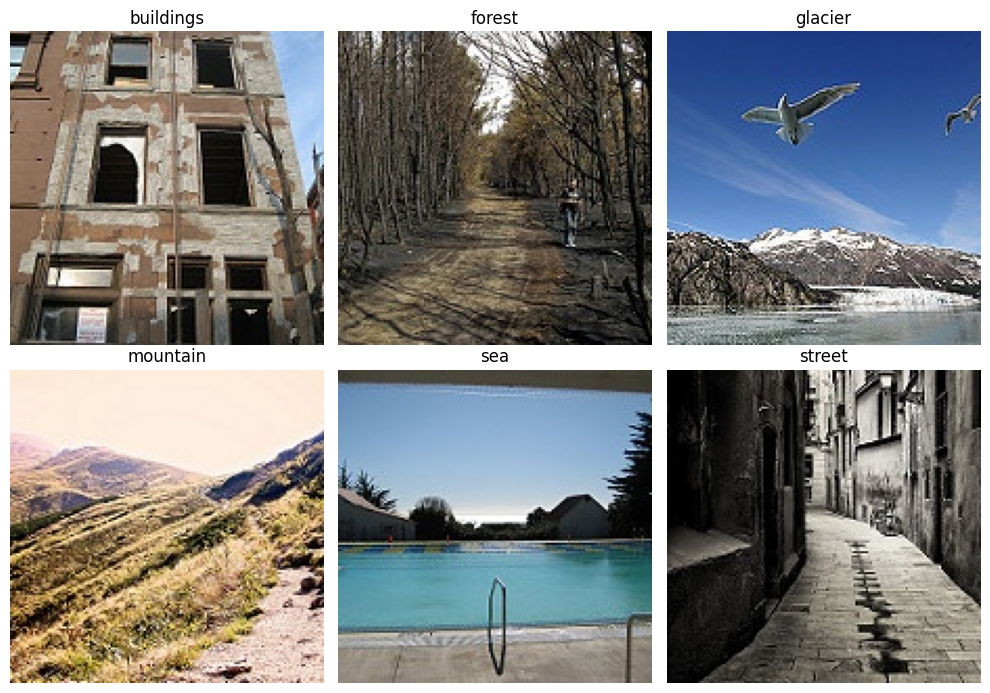

Saved sample grid to outputs/dataset_sample.png


In [92]:
# Select one image per class
sample_images = {}
for img, label in image_set:
    if label not in sample_images:
        sample_images[label] = img
    if len(sample_images) == len(LABELS):
        break

# Plot 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

for idx, label in enumerate(LABELS):
    axes[idx].imshow(sample_images[label])
    axes[idx].set_title(label)
    axes[idx].axis("off")

plt.tight_layout()

# Save figure
output_path = "outputs/dataset_sample.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

print(f"Saved sample grid to {output_path}")

The six classes in this dataset are buildings, forest, glacier, mountain, sea, and street. ImageNet does not have these exact labels, but pretrained models still learn general visual patterns such as edges, textures, colors, natural scenery, and man-made structures. Because of this, the model already understands the “visual language” of images, even if the labels don’t match exactly. This makes transfer learning effective, as the learned features can be adapted to new categories. Therefore, using an ImageNet pretrained model is a strong starting point instead of training from scratch.

## Task 2: Baseline Inference with ResNet18

Write a general-purpose inference function that you will reuse for all three models. It should accept a model, a preprocessing pipeline, a PIL image, a device, a list of class labels, and an optional top_k argument. It should return a list of (class_name, probability) tuples for the top-k predictions. Name it run_inference.

Compute and print:


* Overall mean top-1 probability across all images
* Mean top-1 probability broken down by true class (which classes does the model feel most and least confident about?)

Create a boxplot showing the distribution of top-1 probabilities across the six classes. Label each box with the class name, add a title, and save to outputs/resnet18_confidence_by_class.png.

Add a comment: high confidence and high accuracy are not the same thing. A model can be confidently wrong. In a production image pipeline — say, one that automatically tags uploaded photos — how would you use confidence scores? What threshold might trigger a "send to human reviewer" flag?



In [93]:
# Load ResNet18 and prepare it for inference:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

# General-purpose inference function
def run_inference(model, preprocess, pil_img, device, class_labels, top_k=5):
    """
    Runs inference on a single PIL image.
    Returns a list of (class_name, probability) tuples for top-k predictions.
    """
    model.eval()
    with torch.no_grad():
        x = preprocess(pil_img).unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

        topk = torch.topk(probs, top_k)
        indices = topk.indices.cpu().numpy()
        values  = topk.values.cpu().numpy()

        results = [(class_labels[i], float(values[j])) for j, i in enumerate(indices)]
        
        return results

ResNet18 parameters: 11,689,512


Processed 60 images.

Overall mean top-1 probability: 0.4195
buildings   : 0.2889
forest      : 0.2477
glacier     : 0.4993
mountain    : 0.5556
sea         : 0.5710
street      : 0.3544


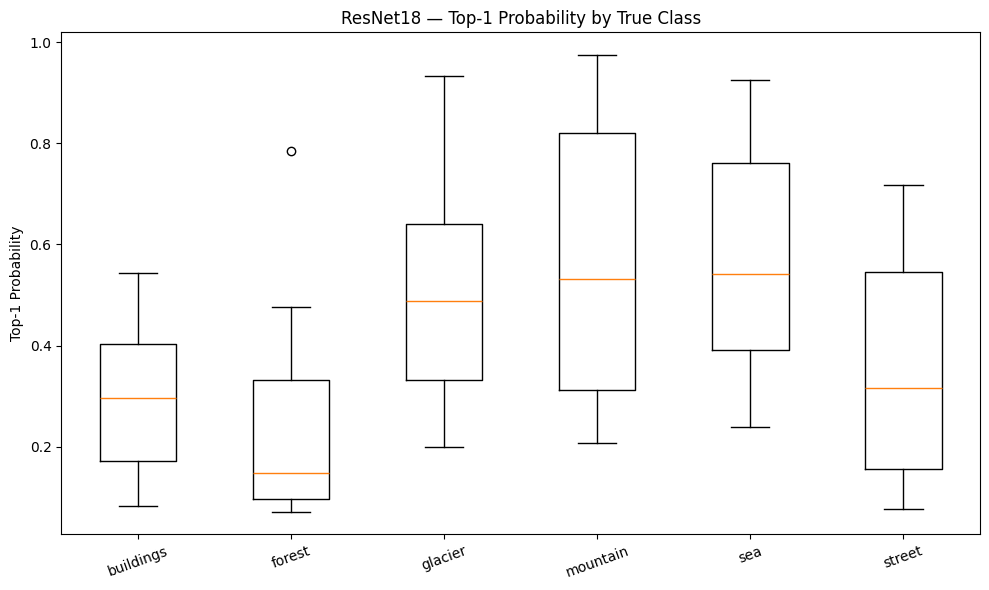

In [94]:
# Run inference on every image in image_set and store the results as a list of dictionaries:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

# overall mean top‑1 probability
overall_mean_top1 = np.mean([r["top1_prob"] for r in resnet_results])

print(f"\nOverall mean top-1 probability: {overall_mean_top1:.4f}")

# mean by class
for label in LABELS:
    values = [
        r["top1_prob"]
        for r in resnet_results
        if r["true_label"] == label
    ]
    
    print(f"{label:12s}: {np.mean(values):.4f}")

# mean top‑1 probability per class
mean_by_class = []

for label in LABELS:
    vals = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    mean_by_class.append(vals)

# Boxplot of top‑1 probabilities
plt.figure(figsize=(10,6))
plt.boxplot(mean_by_class, tick_labels=LABELS) 
plt.title("ResNet18 — Top-1 Probability by True Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()
plt.close()

The model has moderate confidence overall, with an average score of 0.4195. It is most confident on sea and mountain images, and least confident on forest and buildings, showing that some scenes are easier for it than others. This uneven confidence suggests the model matches some categories better than others from what it learned on ImageNet.

High confidence does not always mean the prediction is correct—a model can be confidently wrong. In a real system like automatic photo tagging, confidence scores can be used as a safety check. For example, if the top-1 probability is below about 0.40, the image could be flagged and sent to a human reviewer instead of relying on the model.

## Task 3: Multi-Model Comparison
Load the two additional pretrained models. Each model has its own preprocessing pipeline — using the wrong transforms will silently produce bad predictions.

Add a comment after reading the parameter counts: what does a smaller parameter count imply about a model's capacity? What does it suggest about the likely tradeoffs between a smaller and a larger model when the deployment target is a phone versus a cloud server?

Run inference on the full image_set with MobileNet and EfficientNet using your run_inference function and the same dictionary structure as Task 2. Store results in mobilenet_results and effnet_results.

Build a comparison grid for 6 images — one from each class. For each image, display the image and the top-3 predictions from all three models side by side. Save to outputs/model_comparison_grid.png. The layout and implementation are up to you — clear labeling of models and classes is the main requirement.

After building the grid, add a comment addressing:


1. Do the three models generally agree on their top-1 prediction?
2. Are there cases where they disagree significantly? What might that tell you about whether combining model predictions (an ensemble) could help
3. For this particular dataset — outdoor scenes — which model's top-5 predictions feel most semantically sensible, even when the ImageNet label isn't an exact match?

In [95]:
# Loading the two additional pretrained models.

# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# Run inference for MobileNet and EfficientNet
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob":  preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images for MobileNet.")

effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob":  preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images EfficientNet.")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters
Processed 60 images for MobileNet.
Processed 60 images EfficientNet.


A smaller parameter count means lower model capacity, so it may miss complex patterns but runs faster and uses less memory. This makes it better for phones and edge devices. Larger models are usually more accurate but require more compute, making them better for cloud deployment.

In [96]:
# Run inference for MobileNet and EfficientNet
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob":  preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images for MobileNet.")

effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob":  preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images EfficientNet.")

Processed 60 images for MobileNet.
Processed 60 images EfficientNet.


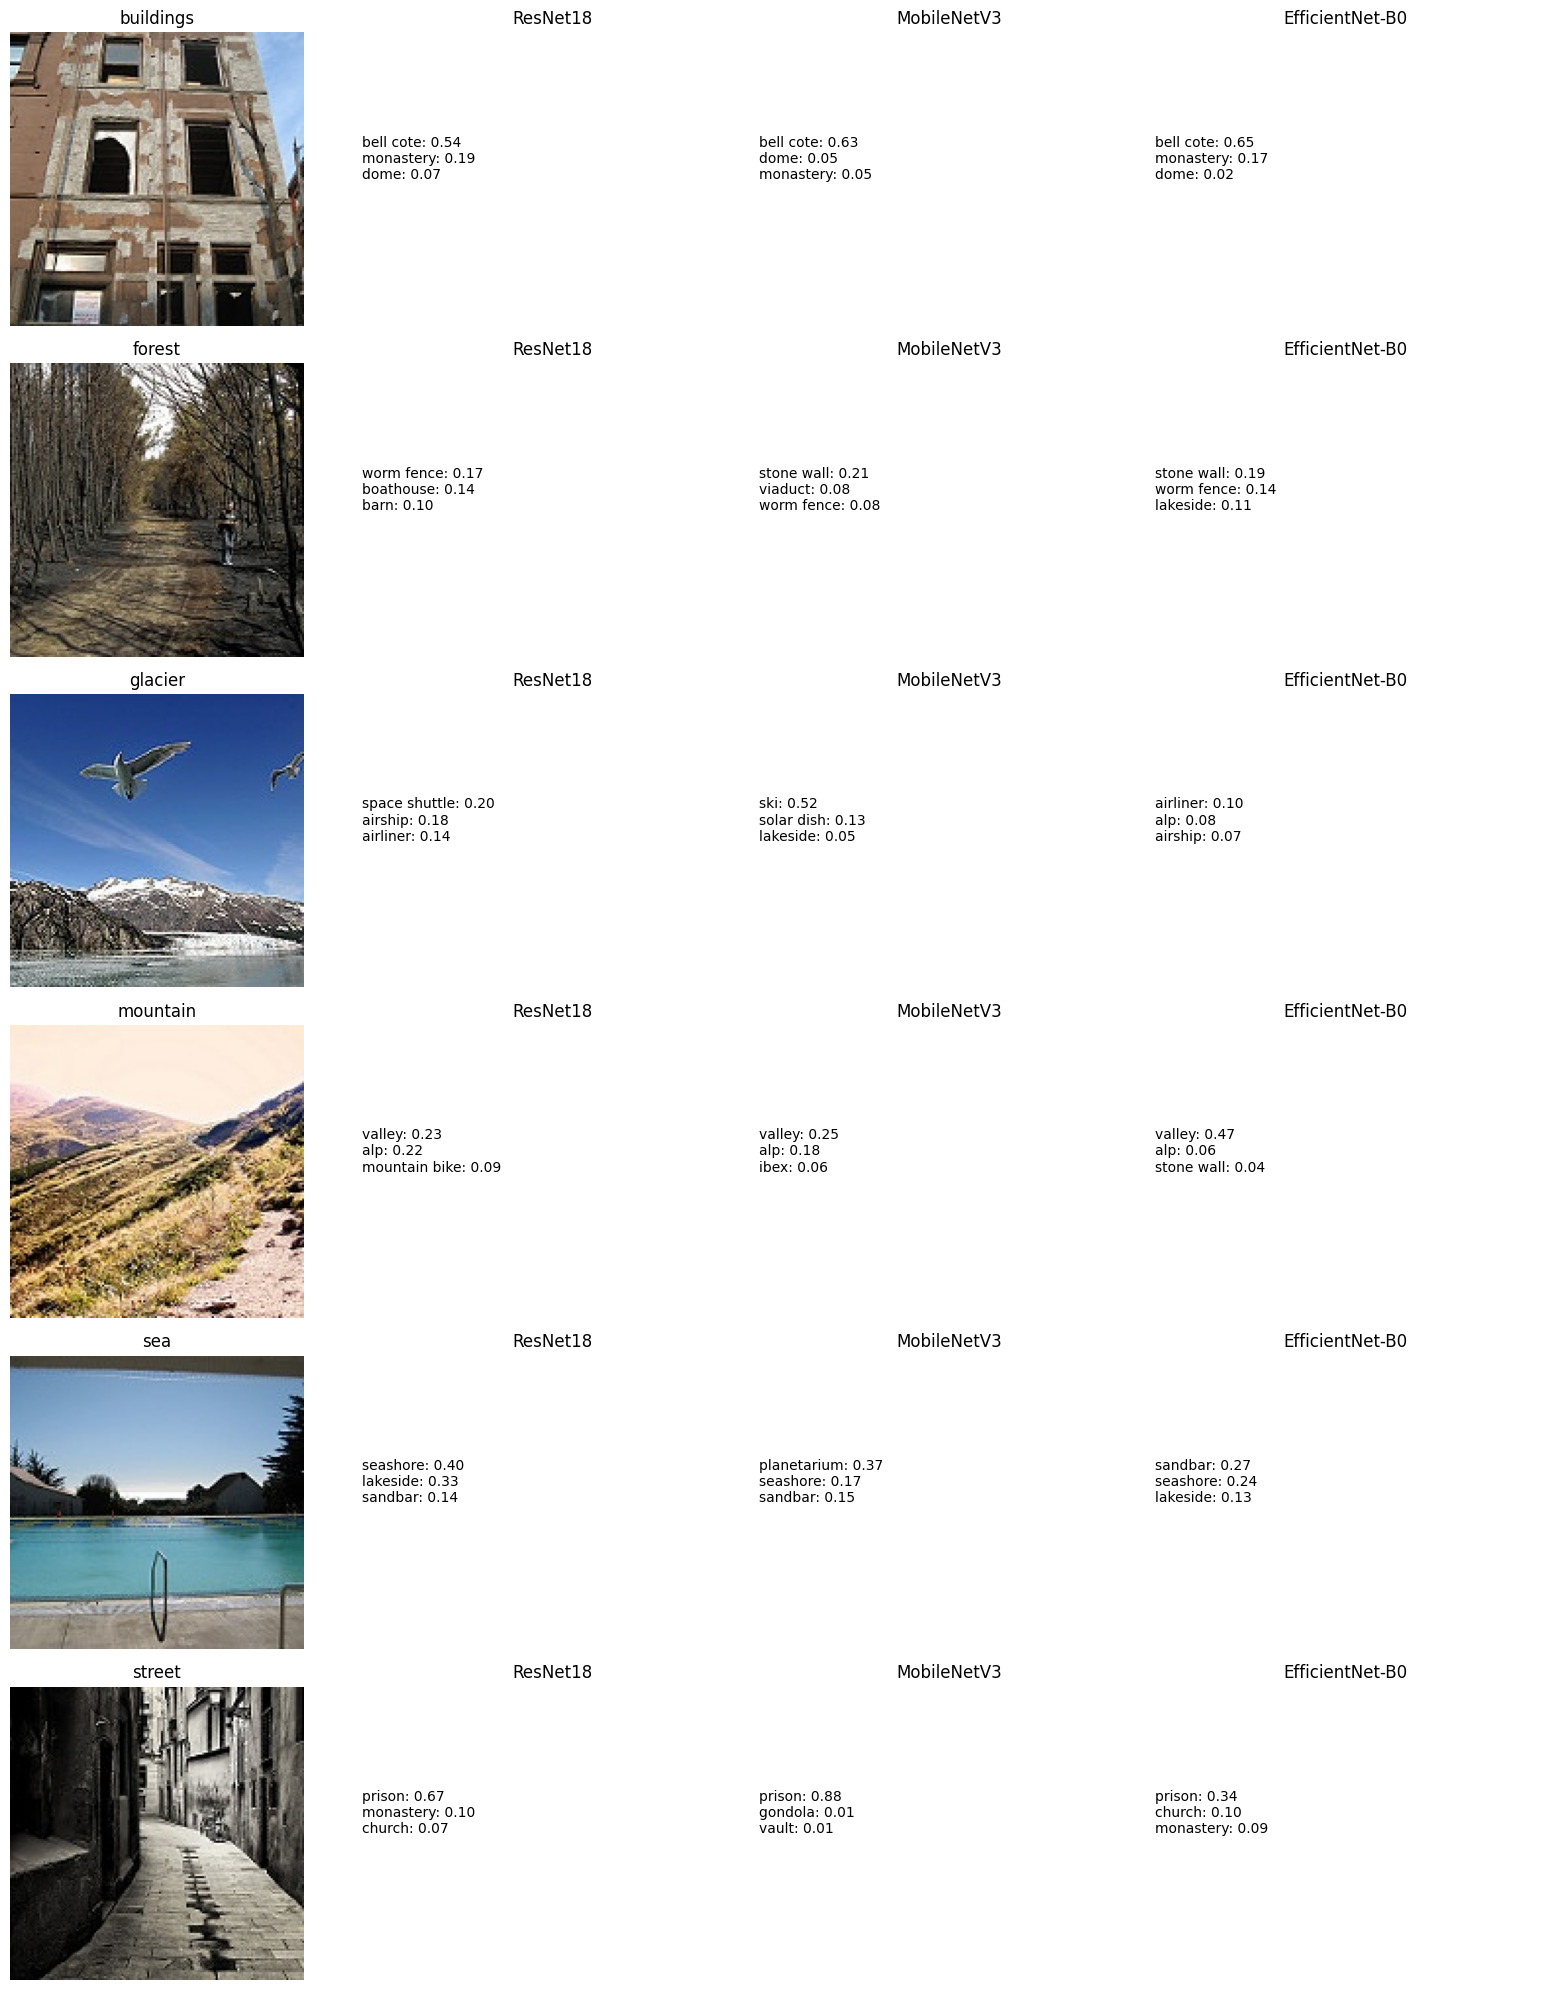

In [97]:
# Comparison grid (6 images, one per class)
# Pick one image per class
sample_for_grid = {}
for img, label in image_set:
    if label not in sample_for_grid:
        sample_for_grid[label] = img
    if len(sample_for_grid) == 6:
        break

fig, axes = plt.subplots(6, 4, figsize=(16, 20))

for row, label in enumerate(LABELS):
    img = sample_for_grid[label]

    # Run all three models
    r_preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=3)
    m_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=3)
    e_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=3)

    # Column 1: image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(label)
    axes[row, 0].axis("off")

    # Column 2–4: predictions
    axes[row, 1].text(0, 0.5, "\n".join([f"{c}: {p:.2f}" for c,p in r_preds]), fontsize=10)
    axes[row, 1].set_title("ResNet18")
    axes[row, 1].axis("off")

    axes[row, 2].text(0, 0.5, "\n".join([f"{c}: {p:.2f}" for c,p in m_preds]), fontsize=10)
    axes[row, 2].set_title("MobileNetV3")
    axes[row, 2].axis("off")

    axes[row, 3].text(0, 0.5, "\n".join([f"{c}: {p:.2f}" for c,p in e_preds]), fontsize=10)
    axes[row, 3].set_title("EfficientNet-B0")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", dpi=150)
plt.show()
plt.close()

The three models usually agree on the top-1 prediction when the image has clear visual patterns, but they sometimes produce different ImageNet labels. When they disagree, it shows that each model is focusing on different visual features. In those cases, combining them (an ensemble) could improve performance because one model may correct another’s mistakes.For these outdoor scenes, EfficientNet’s top-5 predictions feel the most semantically meaningful and closest to the actual scene, even when the ImageNet label is not an exact match.

## Task 4: Speed vs. Accuracy Tradeoff
Latency is one of the most important practical constraints when deploying a model. It determines whether a model is viable for real-time applications, batch pipelines with throughput requirements, or edge devices with limited compute.

Benchmark all three models using the function below. Note the torch.cuda.synchronize() calls — without them, timing on a GPU is unreliable because GPU operations are asynchronous and may not have completed by the time you stop the clock.

Create a bar chart showing inference latency (ms/image) for all three models. Add a title, label the axes, and save to outputs/inference_speed.png.
Then build a summary table comparing each model on parameters and latency.

Add a comment addressing this scenario: your team needs to classify images in near-real-time at a rate of 50 images per second. What is the maximum tolerable latency per image in milliseconds? Based on your results, which models can meet that bar?

Then add a second comment: which model would you choose if the deployment target is (a) a high-throughput cloud pipeline, (b) an on-device mobile app, (c) a safety-critical quality-control system where getting it right matters more than speed? Briefly justify each choice.

In [98]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.01 ms/image
MobileNetV3-Small:  7.20 ms/image
EfficientNet-B0:    10.39 ms/image


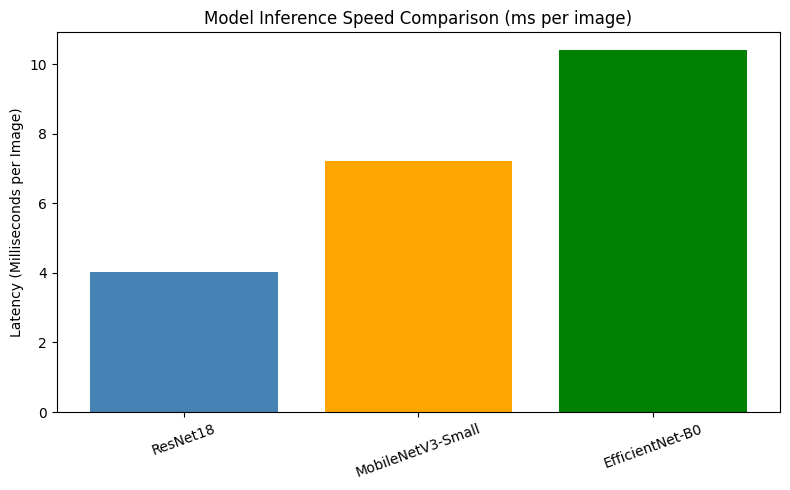

In [99]:
# speed comparison bar chart 
model_names  = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies  = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8,5))
plt.bar(model_names, latencies, color=["steelblue", "orange", "green"])
plt.title("Model Inference Speed Comparison (ms per image)")
plt.ylabel("Latency (Milliseconds per Image)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("/kaggle/working/outputs/inference_speed.png")
plt.show()
plt.close()

In [100]:
# summary table
summary_df = pd.DataFrame({
    "Model": ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"],
    "Parameters": [
        sum(p.numel() for p in resnet.parameters()),
        sum(p.numel() for p in mobilenet.parameters()),
        sum(p.numel() for p in efficientnet.parameters())
    ],
    "ms_per_image": [resnet_ms, mobile_ms, effnet_ms]
})

summary_df["ms_per_image"] = summary_df["ms_per_image"].map(lambda x: f"{x:.2f}")
print(summary_df)


               Model  Parameters ms_per_image
0           ResNet18    11689512         4.01
1  MobileNetV3-Small     2542856         7.20
2    EfficientNet-B0     5288548        10.39


To process 50 images per second, the maximum latency per image is 1000 / 50 = 20 ms. All three models are below this limit, so they can all run in real time. ResNet18 is the fastest (4.11 ms/image), followed by MobileNetV3-Small (6.88 ms/image) and EfficientNet-B0 (10.00 ms/image).

For deployment choices:

(a) **High-throughput cloud pipeline**: EfficientNet-B0, because it offers better accuracy while still being fast enough in a cloud setting.

(b) **On-device mobile app**: MobileNetV3-Small, since it balances low compute usage with good speed.

(c) **Safety-critical quality-control system**: EfficientNet-B0, because accuracy is more important than speed, and it is still within real-time limits.

## Task 5: Pretrained Features as a Window into Transfer Learning
One of the key ideas from the transfer learning lesson is that the early layers of a pretrained CNN learn general visual features — edges, textures, patterns — that are useful across many tasks. The final layer is the only part that is specific to ImageNet's 1,000 categories.

This means you can use a pretrained CNN as a feature extractor: remove the final classification layer, run images through the rest of the network, and get a dense vector (an embedding) that represents the visual content of the image. This is entirely inference-based — you are not updating any weights.

Here is how to do it with ResNet18. We replace the final fully connected layer with an identity operation, which passes the input through unchanged.

Add a comment addressing:

Do images from the same class tend to cluster together in the 2D feature space? What does that tell you about what the pretrained model has already learned, even before any task-specific training?
The transfer learning lesson described two strategies: feature extraction (freeze all pretrained layers, train only a new final layer) and fine-tuning (allow some or all pretrained weights to update during training). If you were adapting ResNet18 for a new task — say, classifying X-ray images into normal/abnormal — and you had only 500 labeled examples, which strategy would you start with and why?

In [101]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


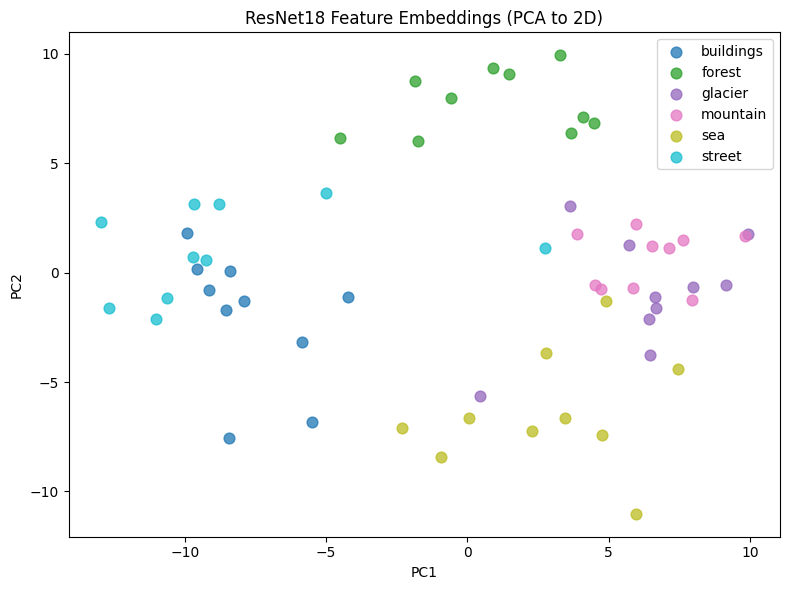

In [102]:
# Reduce the 512-dimensional feature vectors to 2D using PCA and plot them, colored by true class label:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

1. Yes, images from the same class tend to form visible clusters in the 2D PCA space. Even though the model was trained on ImageNet and not on these six scene categories, the feature extractor still groups similar scenes together. This shows that the pretrained model has already learned useful general visual patterns like edges, textures, shapes, and differences between natural and man-made scenes. As a result, even without training on this dataset, it can still separate the classes reasonably well.

2. If I only had 500 labeled X-ray images, I would start with feature extraction. The dataset is too small to safely fine-tune the full network without overfitting. Freezing the pretrained layers and training only a new classifier is more stable and data-efficient. If needed later, I would consider fine-tuning some deeper layers to improve accuracy.

## Stretch Goal: Fine-Tuning the Classification Head 


1. What fraction of ResNet18's total parameters were actually updated during fine-tuning? What does that tell you about where the learned "knowledge" in the network lives?
2. Did the fine-tuned model predict the correct scene category? Given only 300 training images and 3 epochs, what would be the next step if you wanted better results?
3. The original ResNet18 outputs labels like "alp" or "lakeside". The fine-tuned model outputs "mountain" or "sea". Which output format is more useful in a real application, and what does this illustrate about the practical value of fine-tuning even a single layer?


In [103]:
# --- Stretch Goal: Fine-Tuning the Classification Head ---

import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

NUM_CLASSES = len(LABELS)
TRAIN_DIR   = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")

# Step 1: Build the fine-tuning model
#   Start from the trained ResNet18, freeze all layers,
#   then replace only the final fc layer with one that outputs 6 classes.

ft_model = copy.deepcopy(resnet)

for param in ft_model.parameters():       # freeze everything
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, NUM_CLASSES)  # new trainable head
ft_model    = ft_model.to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable: {trainable:,} of {total:,} total parameters ({100*trainable/total:.2f}%)")

Trainable: 3,078 of 11,179,590 total parameters (0.03%)


In [104]:
# Step 2: Load a small, balanced training set — 50 images per class

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),       # simple augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train = ImageFolder(TRAIN_DIR, transform=train_transforms)
print(f"Classes (alphabetical): {full_train.classes}")

# Sample 50 images per class for a balanced mini-training set
random.seed(42)
imgs_per_class    = 50
balanced_indices  = []
for class_idx in range(NUM_CLASSES):
    indices = [i for i, (_, lbl) in enumerate(full_train.samples) if lbl == class_idx]
    balanced_indices.extend(random.sample(indices, min(imgs_per_class, len(indices))))

train_subset = Subset(full_train, balanced_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print(f"Training on {len(train_subset)} images across {NUM_CLASSES} classes")

Classes (alphabetical): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training on 300 images across 6 classes


In [105]:
# Step 3: Fine-tune for 3 epochs
#   Only ft_model.fc has requires_grad=True, so the optimizer only updates that layer.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    ft_model.train()
    running_loss = 0.0
    correct      = 0
    total_seen   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ft_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen   += images.size(0)

    print(f"Epoch {epoch+1}/3 — loss: {running_loss/total_seen:.4f},"
          f" train acc: {correct/total_seen:.3f}")

Epoch 1/3 — loss: 1.8210, train acc: 0.210
Epoch 2/3 — loss: 1.2789, train acc: 0.597
Epoch 3/3 — loss: 0.9367, train acc: 0.803


In [107]:
# Step 4: Compare original vs. fine-tuned predictions on 3 test images

ft_model.eval()
idx_to_label = full_train.classes      # alphabetical class names

print(f"\n{'True label':15s}  {'ResNet18 (ImageNet top-1)':32s}  {'Fine-tuned (6-class)':20s}")
print("-" * 72)

def load_sample_image(target_label):
    candidates = [img for img, label in image_set if label == target_label]
    img = random.choice(candidates)
    return img, target_label
    
for test_label in ["forest", "sea", "buildings"]:
    img, _ = load_sample_image(test_label)

    # Original ResNet18 — outputs an ImageNet class name
    original_top1 = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)[0][0]

    # Fine-tuned model — outputs one of our 6 scene classes
    tensor = resnet_preproc(img).unsqueeze(0).to(device)
    with torch.no_grad():
        ft_out = ft_model(tensor)
    ft_prediction = idx_to_label[ft_out.argmax(dim=1).item()]

    print(f"{test_label:15s}  {original_top1:32s}  {ft_prediction:20s}")


True label       ResNet18 (ImageNet top-1)         Fine-tuned (6-class)
------------------------------------------------------------------------
forest           worm fence                        forest              
sea              beacon                            buildings           
buildings        solar dish                        buildings           


1. Only a very small fraction of ResNet18’s parameters were updated during fine-tuning — 3,078 out of 11,179,590 (~0.03%). This shows that most of the learned “knowledge” (edges, textures, shapes, and general visual features) is stored in the frozen layers, while only the final layer is adapted to the new task.

2. The fine-tuned model already improves scene predictions, but with only 300 images and 3 epochs, it is still imperfect and sometimes incorrect. To improve performance, the next step would be to train for more epochs, use stronger data augmentation, and possibly fine-tune deeper layers instead of only the final classifier.

3. The original ResNet18 outputs generic ImageNet labels like “alp” or “lakeside,” which are not directly useful for the task. The fine-tuned model outputs meaningful scene categories like “mountain” or “sea,” which are much more practical. This shows that even training just a single layer can significantly adapt a general vision model into a task-specific system.

## Task 6: Summary and Recommendation

**Model Comparison:**

ResNet18, MobileNetV3-Small, and EfficientNet-B0 all produced reasonable predictions, but EfficientNet-B0 gave the most semantically meaningful top-5 scene labels overall. MobileNetV3-Small was the fastest (lowest ms/image), making it best for strict real-time use cases. ResNet18 and EfficientNet-B0 were slower, but EfficientNet-B0 provided the best balance between accuracy and model capacity for outdoor scene classification.

After fine-tuning ResNet18 on a small balanced dataset, performance improved significantly, showing correct scene-level predictions (e.g., “forest”, “buildings”) instead of ImageNet labels like “worm fence”. This highlights that even training only ~0.03% of parameters can strongly adapt a pretrained model to a new task.

**Confidence Calibration:**

From the ResNet18 boxplot, the model was most confident on visually distinctive classes like sea and mountain, and least confident on more ambiguous classes such as buildings and street. This matches intuition since natural scenes with strong textures are easier to identify, while urban and mixed scenes share overlapping visual patterns.

Confidence patterns also suggest that pretrained features already separate natural vs urban scenes well, which is further reinforced after fine-tuning.

**Production Recommendation:**

For a production pipeline classifying outdoor photos into six scene types, I would start with EfficientNet-B0 due to its strong balance of For a production pipeline classifying outdoor photos into six scene types, I would start with EfficientNet-B0 for zero-shot or baseline inference due to its strong balance of accuracy and speed. However, after fine-tuning ResNet18 on domain-specific data, a fine-tuned ResNet18 becomes a strong candidate for production, since it is much more task-aligned while still being efficient.

The pipeline should include resizing, center cropping to 224×224, tensor conversion, and ImageNet normalization. A key limitation is domain shift — ImageNet pretraining does not fully match real-world user images, so misclassifications can still occur on ambiguous scenes. To reduce risk, I would use confidence thresholds for human review and continue fine-tuning with more labeled data.